# Homework: Multimodal Models - Image Captioning and Visual Question Answering

**Goal**

In this assignment, you will experiment with multimodal models that combine vision and language.

You will use a pretrained model to:

1. Generate a caption for an image.
2. Answer questions about an image.

You will also analyze the model's strengths, weaknesses, and possible failure cases.

## Task 1 - Image Captioning (30 Points)

**Description**

Given an input image, use a pretrained multimodal model to generate a textual description of the image.

Example:

**Input**: An image of a dog running in a park.

**Output**: A dog is running on grass in a park.

**Requirements**

Use at least 5 different images.

The images should include:

* At least one image with people
* At least one image with animals
* At least one indoor scene
* At least one outdoor scene
* At least one image with multiple objects

You may use your own images or images from an open dataset.

**Suggested Models**

You may use one of the following:

* Salesforce/blip-image-captioning-base
* Salesforce/blip-image-captioning-large
* microsoft/git-base
* Any other image-captioning model from HuggingFace

**Deliverables**

1. Present your images and model captions clearly

    Display each image together with the caption generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    For example :

    "The model described the image as “a person sitting at a table,” but it missed the laptop and the coffee cup.
    This may have happened because the person was the most visually dominant object, while the smaller objects were less noticeable."


In [ ]:
%pip install -q transformers torch pillow matplotlib requests


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

MODEL_NAME = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.eval()
print(f"Loaded {MODEL_NAME}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.8.0).
W0615 00:48:47.009000 17798 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loaded Salesforce/blip-image-captioning-base


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
from PIL import Image
import requests
from io import BytesIO

def load_image(src):
    """Return a PIL RGB image from a URL or a local file path."""
    if src.startswith("http"):
        resp = requests.get(src, timeout=20)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content))
    else:
        img = Image.open(src)
    return img.convert("RGB")

In [ ]:
images = {
    "people":          load_image("/Users/yahelcohen/Desktop/notebooks/nebius/02-LLM-Architectures/assignment_04/images/lebron.jpg"),
    "animals":         load_image("/Users/yahelcohen/Desktop/notebooks/nebius/02-LLM-Architectures/assignment_04/images/panda.jpg"),
    "indoor":          load_image("/Users/yahelcohen/Desktop/notebooks/nebius/02-LLM-Architectures/assignment_04/images/kitchen.jpeg"),
    "outdoor":         load_image("/Users/yahelcohen/Desktop/notebooks/nebius/02-LLM-Architectures/assignment_04/images/mountain.jpg"),
    "multiple_objects": load_image("/Users/yahelcohen/Desktop/notebooks/nebius/02-LLM-Architectures/assignment_04/images/sports-balls.jpeg"),
}

assert len(images) >= 5, "Need at least 5 images to satisfy the requirements."

In [ ]:
def generate_caption(image):
    inputs = processor(images=image, return_tensors="pt")        # TODO
    out = model.generate(**inputs, max_new_tokens=30)           # TODO
    caption = processor.decode(out[0], skip_special_tokens=True)       # TODO
    return caption.strip()



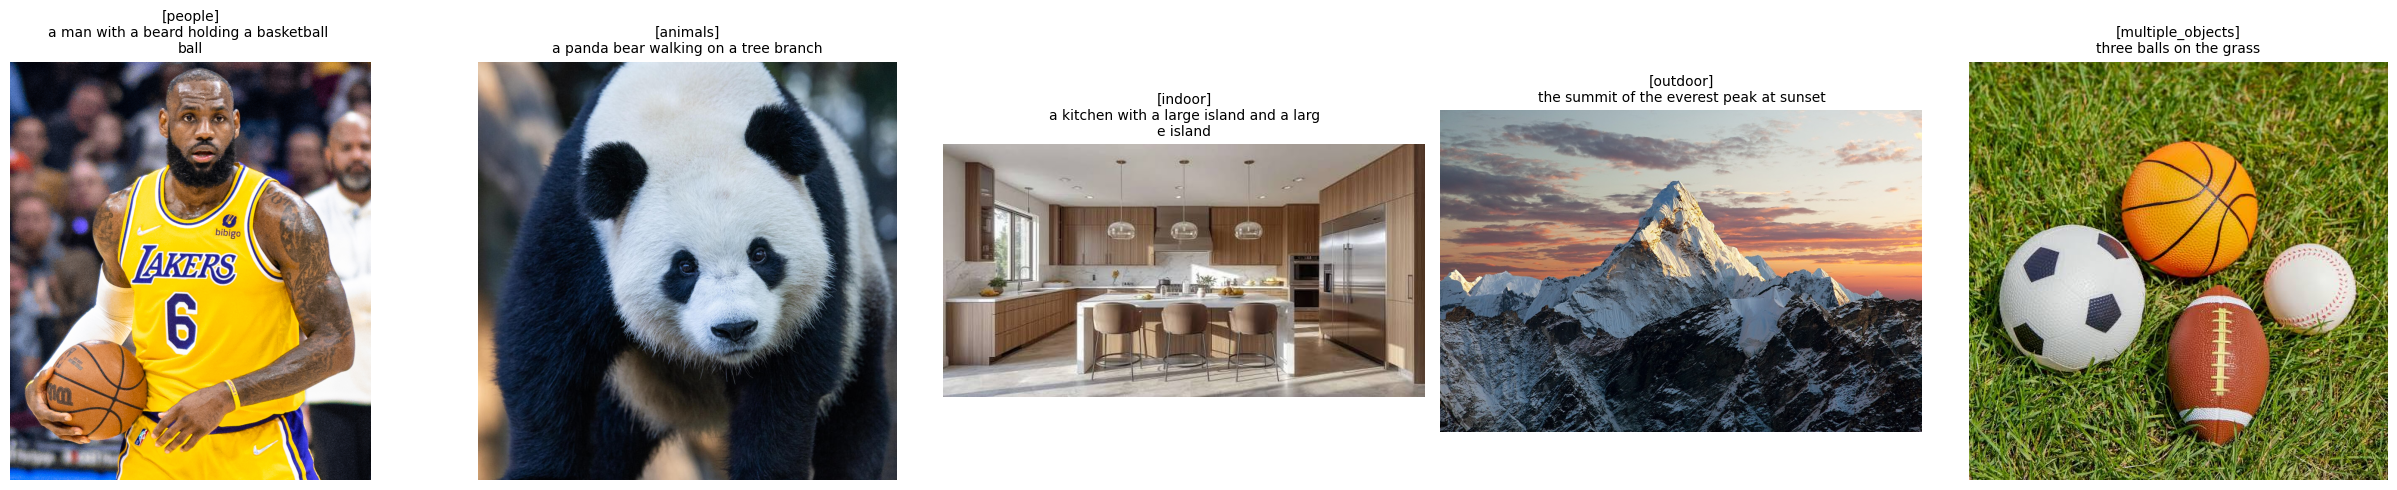

In [ ]:
import matplotlib.pyplot as plt

n = len(images)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, (category, image) in zip(axes, images.items()):
    caption = generate_caption(image)
    ax.imshow(image)
    ax.axis("off")
    # wrap long captions so they fit under the image
    wrapped = "\n".join(caption[i:i + 40] for i in range(0, len(caption), 40))
    ax.set_title(f"[{category}]\n{wrapped}", fontsize=10)

plt.tight_layout()
plt.show()

### Deliverable 2 — Failure analysis

Pick **at least 2** captions where the model got it wrong or missed something, and fill in the table below.

| Image | Model predicted | Correct description | Why it likely failed |
|-------|-----------------|---------------------|----------------------|
| _animals_ | _"a panda bear walking on a tree branch"_ | _"a panda bear walking"_ | _the panda was the visually dominant object; you cant tell for sure that the panda is walking on a tree branch_ |
| _multiple objects_ | _"three balls on the grass"_ | _"four balls on the grass"_ | _the model said three balls but there are clearly four_ |

**Notes / discussion:**

_Write 2-4 sentences here connecting your failures to how the model works — e.g. BLIP is trained on web alt-text that favors dominant foreground objects, struggles with counting, text/OCR, fine attributes, or unusual scenes._


As we know BLIP was trained on millions of (image, caption) pairs scraped from the web with human written captions so it tries to copy human captioning habits like name the dominant object, don't count or fill in typical context. In the case of the counting balls error, counting isn't something alt-text teaches, so the model is guessing and the error is expected. The second error shows that the model training data must had a lot of panda with trees environment so its pattern-completes likely surroundings instrad of stating only what's verifiable, a form of hallucination.

## Task 2 - Visual Question Answering (30 points)

**Description**

Given an image and a natural-language question, use a pretrained multimodal model to answer the question.

Example:

**Input image**: A kitchen scene

**Question**: How many chairs are visible?

**Output**: Four.

**Requirements**

Use at least 3 images.

For each image, ask at least 3 questions.

Your questions should include:

* One object-recognition question
* One counting question
* One color or attribute question

Example questions:
* What animal is in the image?
* How many people are visible?
* What color is the car?

**Suggested Models**

You may use:

* Salesforce/blip-vqa-base
* Salesforce/blip-vqa-capfilt-large
* Any other VQA model from HuggingFace

**Deliverables**

1. Present your images, questions and model's answers clearly

    Display each image together with the Q&A generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    **You are required to find examples where it fails and analyse why**


In [ ]:
# code goes here

## Task 3 - Personalized Face Recognition with a Celebrity Dataset (40 points)


**Goal**

Build a small personalized multimodal recognition system.

For this task, you will use a public celebrity face dataset rather than private photos of family or friends.

Although the same approach could easily be adapted to recognize your own friends, family members, or personal image collections, in this assignment you must use a celebrity dataset in order to avoid privacy concerns and to ensure a consistent evaluation setting across all students.

Students who are interested may later explore how the same techniques can be extended to build personalized multimodal recognition systems for recreational or educational purposes outside the scope of this course.

The system should learn to recognize a small set of known identities and answer questions such as:

* Who is in the image?
* Is this person Emma Watson or Leonardo DiCaprio?
* What is Emma doing or wearing?

Recommended datasets:

* CelebA — contains over 200K celebrity face images, 10,177 identities, and 40 attribute annotations. https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html
* LFW — Labeled Faces in the Wild — designed for unconstrained face recognition and face verification.
https://scikit-learn.org/0.19/datasets/labeled_faces.html
* You may also scrape or download images from the internet in order to build your celebrity dataset.

1. Choose 3-5 identities from a celebrity dataset. For each identity, collect at least 8 images.

2. split the images into:
   * Train/reference set: 5-6 images per identity
   * Test/query set: 2-3 images per identity

3. Use a pretrained model to convert each image into an embedding vector. Recommended model : CLIP

4. Compare a query image to the known identity images using cosine similarity

5. Use the predicted identity to answer simple personalized questions.

    Note:

    CLIP similarity predicts who the person is; a VQA/captioning model answers visual attribute/action questions about the image.

    Use this structure:
    1. CLIP similarity → Who is this?
    2. VQA model → What is the person wearing / doing / holding?
    3. Combined answer → “This is probably Emma Watson. She appears to be wearing a black dress.”

              Example:

              Question: Who is in the image?

              Answer: This is probably Emma Watson.

              Question: Is this Barack Obama?

              Answer: No, this is probably Taylor Swift.

              Question: What is Emma wearing?

              Answer: The model appears to show Emma wearing a black jacket.

6. Analyze when the system works and when it fails. Show images , Q&A and disscuess results.

In [ ]:
# code goes here